In [1]:
import sys
sys.path.append('..')
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
# from StatTools.generators.multi_scale_fractional_generator import MultiScaleFractionalGenerator
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

from collections import defaultdict
from typing import Optional, Union, Tuple

import numpy as np
from synth import gen_traj, postprocess_collisions, draw_ants_with_direction, draw_traj, build_visible_gt
from nmot import NMOT
from eval import evaluate_mot
from pathlib import Path
import pickle

In [28]:
columns_name = ['metric', 'predhead', 'value']
predhead_names = {'zero':'KNN', 'kalman':'Kalman', 'kalman_ar1':'Kalman AR1', 'kalman_ar2':'Kalman AR2', 'kalman_ar3':'Kalman AR3', 'lucas-kanade':'Lucas-Kanade'}
rename_metrics_dict = {
    'assa_alpha': 'AssA',
    'deta_alpha': 'DetA',
    'hota_alpha': 'HOTA',
    'idf1': 'IDF1',
    'idp': 'IDP',
    'idr': 'IDR',
    'mota': 'MOTA',
    'motp': 'MOTP',
}
metrics_dict_100 = pd.read_pickle('../data/predheads_montecarlo_100.pkl')
metrics_dict_900 = pd.read_pickle('../data/predheads_montecarlo_900.pkl')


metrics_df_100 = pd.concat(metrics_dict_100).melt(ignore_index=False).droplevel(0).reset_index()
metrics_df_900 = pd.concat(metrics_dict_900).melt(ignore_index=False).droplevel(0).reset_index()
metrics_df_100.columns = columns_name
metrics_df_900.columns = columns_name
# metrics_df_100.predhead = metrics_df_100.predhead.replace(predhead_names)
# metrics_df_900.predhead = metrics_df_900.predhead.replace(predhead_names)
metrics_df_300 = pd.read_pickle('../data/artifacts/metrics_300.pkl')
metrics_df_100['ants_num'] = 100
metrics_df_300['ants_num'] = 300
metrics_df_900['ants_num'] = 900

In [29]:
ar_dict = pd.read_pickle('../data/ar_predheads_montecarlo.pkl')
result = []
for ant_num, df in ar_dict.items():
    df = pd.concat(df).reset_index(level=1)
    df = df.melt(id_vars='level_1', var_name='predhead')
    df = df.rename(columns={'level_1':'metric'})
    df['ants_num'] = ant_num
    result.append(df)
df_ar = pd.concat(result)

In [30]:
metrics_df = pd.concat([metrics_df_100, metrics_df_300, metrics_df_900], axis=0)
metrics_df = metrics_df[~metrics_df.predhead.isin(['kalman_ar1', 'Kalman-Kasdin AR1'])]
metrics_df = pd.concat([metrics_df, df_ar], axis=0)
metrics_df.metric = metrics_df.metric.replace(rename_metrics_dict)
metrics_df.predhead = metrics_df.predhead.replace(predhead_names)

In [ ]:
# metrics_df.to_pickle('../data/artifacts/montecarlo_metrics_all_predheads_antsnum.pkl')

In [32]:
rename_metrics_dict = {
    'assa_alpha': 'AssA',
    'deta_alpha': 'DetA',
    'hota_alpha': 'HOTA',
    'idf1': 'IDF1',
    'idp': 'IDP',
    'idr': 'IDR',
    'mota': 'MOTA',
    'motp': 'MOTP',
}

id_family = ['IDF1', 'IDP', 'IDR']
mota_family = ['MOTA', 'MOTP']
hota_family = ['AssA', 'DetA', 'HOTA']

target_metrics = ['AssA', 'DetA', 'HOTA', 'IDF1', 'IDP', 'IDR', 'MOTA', 'MOTP']


# knn kanade kalman-cv

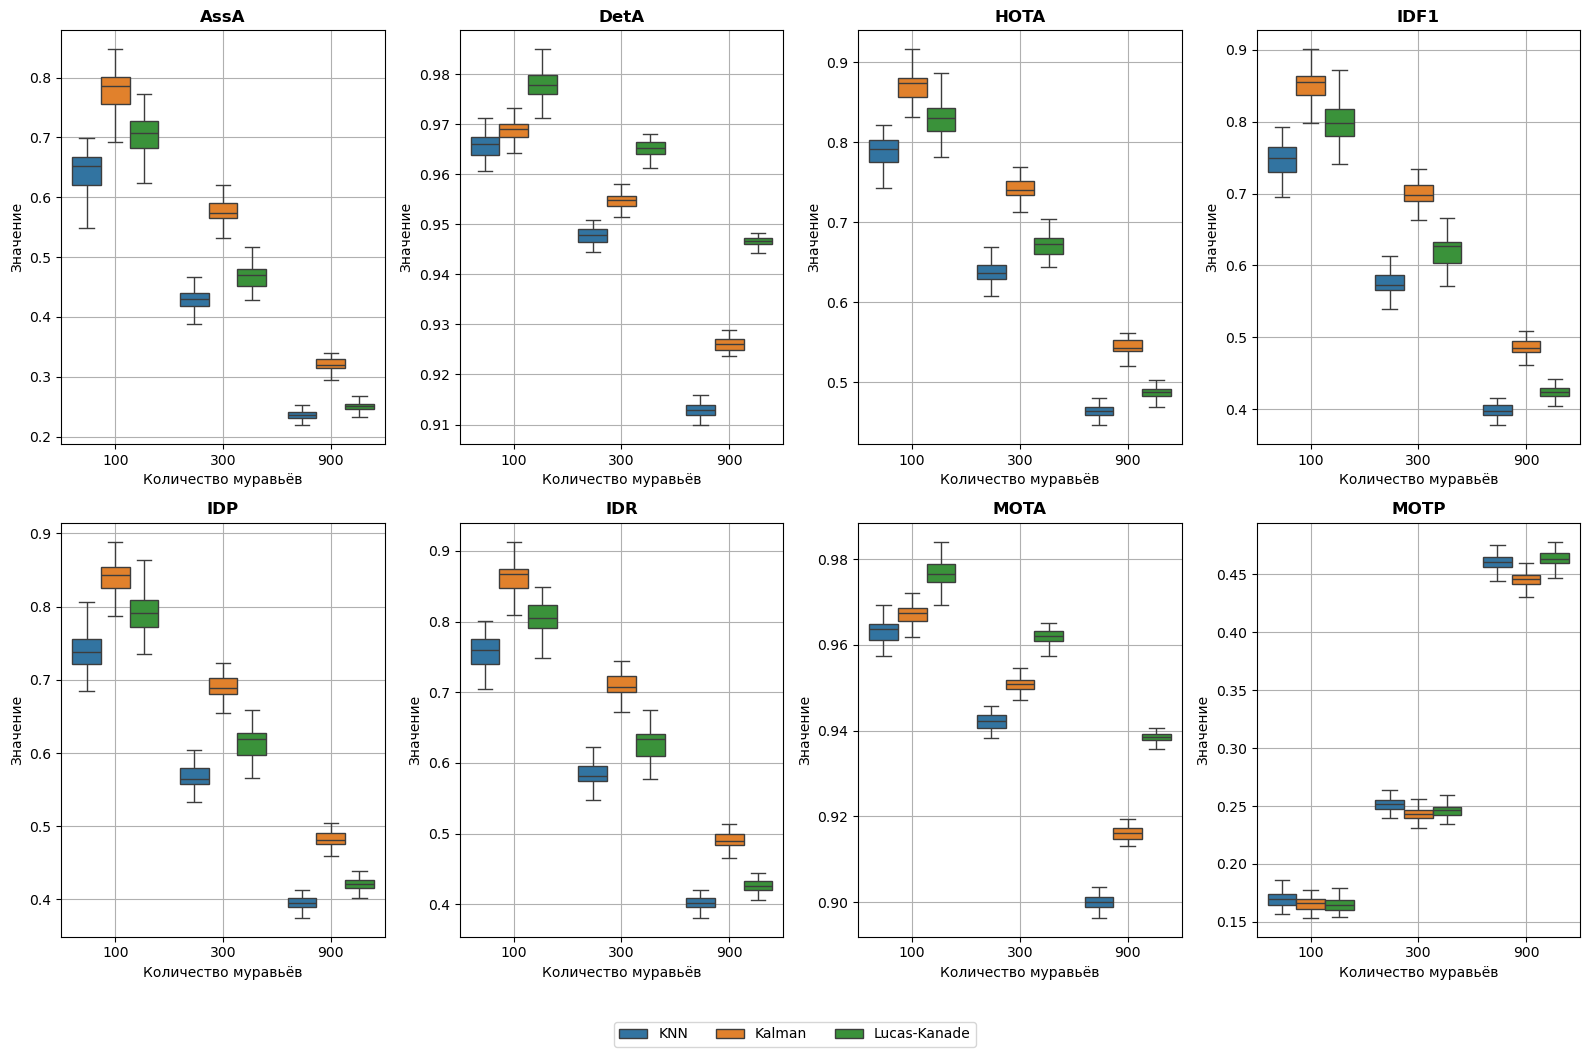

In [35]:
target_predheads = ['KNN', 'Kalman', 'Lucas-Kanade']
filtered_df = metrics_df.loc[metrics_df.metric.isin(target_metrics) & metrics_df.predhead.isin(target_predheads)]

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, metric in enumerate(target_metrics):
    metric_data = filtered_df[filtered_df.metric == metric]
    
    sns.boxplot(
        data=metric_data,
        x='ants_num',
        y='value',
        hue='predhead',
        ax=axes[idx],
        showfliers=False
    )
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Количество муравьёв')
    axes[idx].set_ylabel('Значение')
    
    # Удаляем легенду с каждого подграфика
    axes[idx].get_legend().remove()
    axes[idx].grid()
# Берём легенду из последнего графика и создаём одну общую
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, frameon=True)

plt.tight_layout()

plt.show()
fig.savefig('../data/artifacts/ant_num_metrics_degradation.png', bbox_inches='tight')


# all predheads

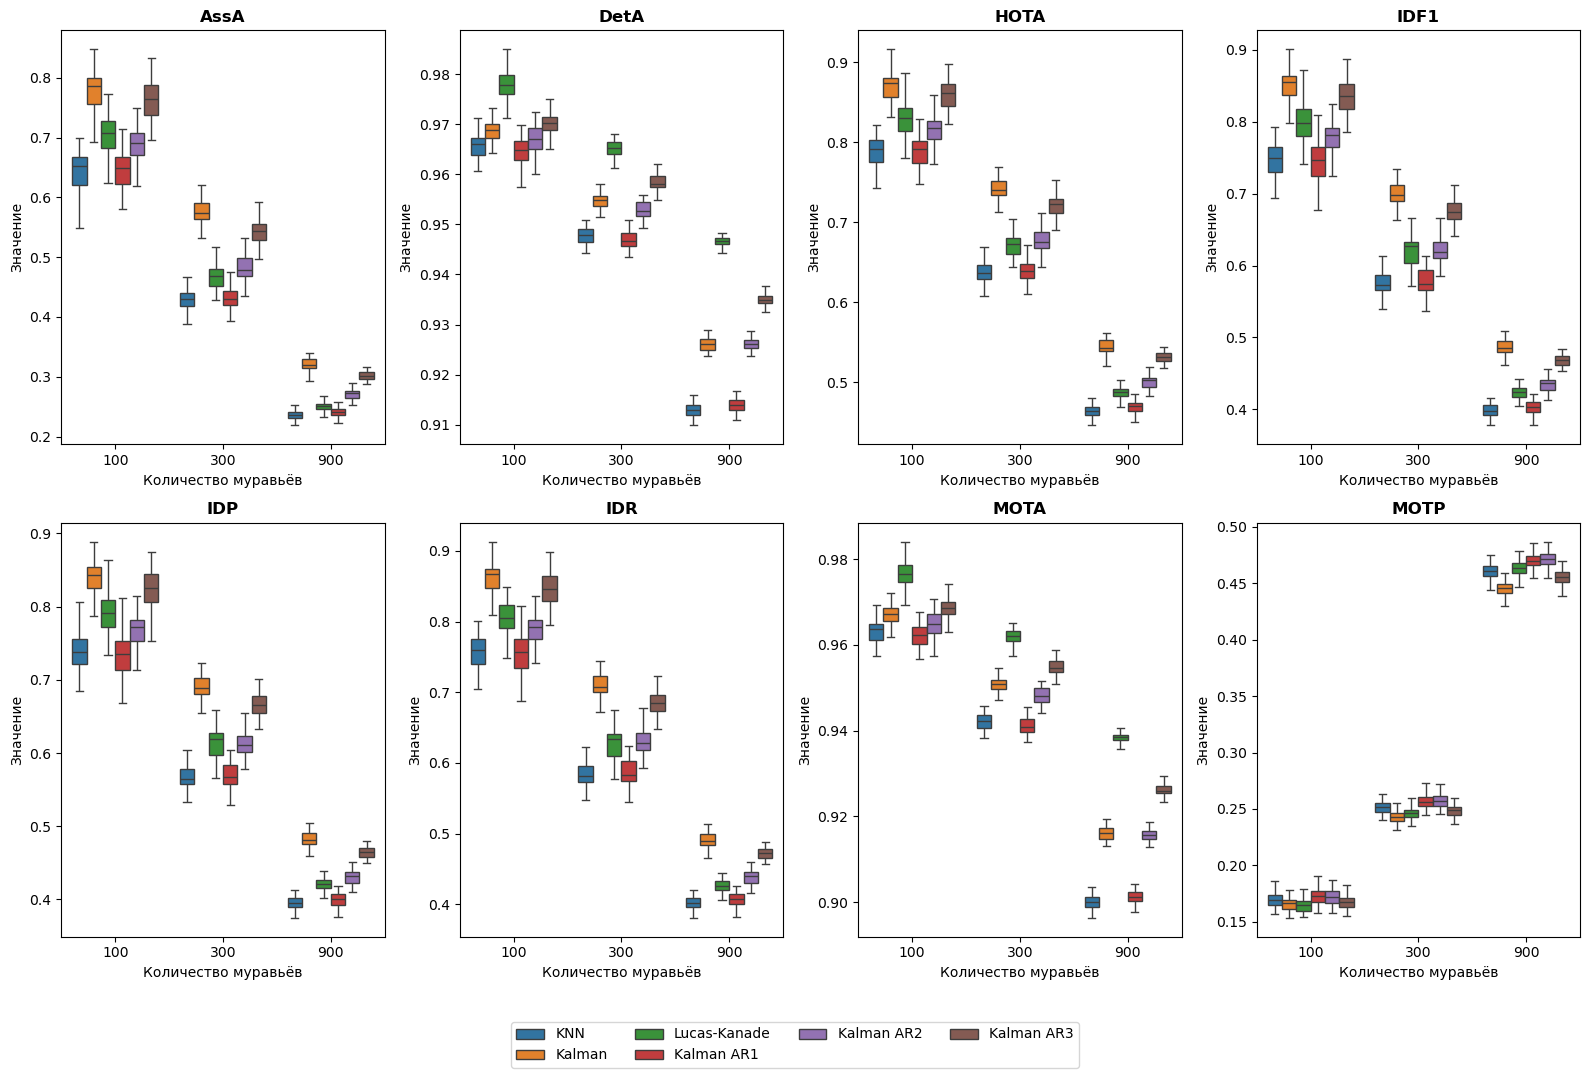

In [33]:


filtered_df = metrics_df.loc[metrics_df.metric.isin(target_metrics)]

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, metric in enumerate(target_metrics):
    metric_data = filtered_df[filtered_df.metric == metric]
    
    sns.boxplot(
        data=metric_data,
        x='ants_num',
        y='value',
        hue='predhead',
        ax=axes[idx],
        showfliers=False
    )
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Количество муравьёв')
    axes[idx].set_ylabel('Значение')
    
    # Удаляем легенду с каждого подграфика
    axes[idx].get_legend().remove()

# Берём легенду из последнего графика и создаём одну общую
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, frameon=True)

plt.tight_layout()

plt.show()
fig.savefig('../data/artifacts/ant_num_metrics_degradation.png', bbox_inches='tight')


In [ ]:

# latex_code = medians_table.to_latex(
#     index=True,
#     float_format=lambda x: f'{x:.2f}' if x<1 else f'{x:.0f}',
#     escape=False
# )
# with open('../data/artifacts/metrics_table.tex', 'w', encoding='utf-8') as f:
#     f.write(latex_code)
